In [98]:
import pandas as pd
import matplotlib.pyplot as plt

## Carga de archivo principal

En este caso se uso el archivo tvar_crea porque ya qu es el archivo que contiene las horas dedicadas a cada activida

In [99]:
dataTiempos = pd.read_csv('../Data/Tiempo/enut_2024_bd_csv/tvar_crea.csv')

In [100]:
dataTiempos

,LLAVEMOD,LLAVEVIV,LLAVEHOG,ACTIV_PROD_CON_CP,ACTIV_PROD_SIN_CP,ACTIV_MERC,TRAB_MERC_PV,TRAS_TRAB,BUS_TRAB,PROD_BIEN_TRAB_AUTO,...,COND_IND,COND_DISC,COND_AEE,EST_DIS,UPM_DIS,FAC_PER,CONTROL,VIV_SEL,HOGAR,N_REN
0,10039503105,10039503,100395031,25.833333,25.833333,0.000000,0.0,0.000000,0.0,0.000000,...,2,2,5,3,19,590,100395,3,1,5
1,10039504101,10039504,100395041,30.166667,30.166667,23.083333,22.0,1.083333,0.0,0.000000,...,2,2,1,3,19,599,100395,4,1,1
2,10039504102,10039504,100395041,71.750000,71.750000,8.833333,8.0,0.833333,0.0,0.000000,...,2,2,1,3,19,580,100395,4,1,2
3,10039504103,10039504,100395041,17.416667,17.416667,0.000000,0.0,0.000000,0.0,0.000000,...,2,2,4,3,19,591,100395,4,1,3
4,10039504104,10039504,100395041,20.583333,20.583333,13.000000,12.0,1.000000,0.0,0.000000,...,2,2,1,3,19,592,100395,4,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74048,326048703101,326048703,3260487031,33.833333,33.833333,0.000000,0.0,0.000000,0.0,2.000000,...,2,2,5,342,4197,587,3260487,3,1,1
74049,326103520101,326103520,3261035201,56.500000,56.500000,30.000000,24.0,6.000000,0.0,0.000000,...,2,2,1,342,4203,586,3261035,20,1,1
74050,326103520102,326103520,3261035201,63.500000,49.500000,0.000000,0.0,0.000000,0.0,0.000000,...,2,2,5,342,4203,576,3261035,20,1,2
74051,326103520103,326103520,3261035201,6.350000,6.350000,0.000000,0.0,0.000000,0.0,0.000000,...,2,2,4,342,4203,588,3261035,20,1,3


In [101]:
dataTiempos.info()

<class 'pandas.DataFrame'>
RangeIndex: 74053 entries, 0 to 74052
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   LLAVEMOD                 74053 non-null  int64  
 1   LLAVEVIV                 74053 non-null  int64  
 2   LLAVEHOG                 74053 non-null  int64  
 3   ACTIV_PROD_CON_CP        74053 non-null  float64
 4   ACTIV_PROD_SIN_CP        74053 non-null  float64
 5   ACTIV_MERC               74053 non-null  float64
 6   TRAB_MERC_PV             74053 non-null  float64
 7   TRAS_TRAB                74053 non-null  float64
 8   BUS_TRAB                 74053 non-null  float64
 9   PROD_BIEN_TRAB_AUTO      74053 non-null  float64
 10  TRAB_NO_REM_VOL          74053 non-null  float64
 11  TRAB_NO_REM_HOG          74053 non-null  float64
 12  PREP_SERV_ALIM           74053 non-null  float64
 13  LIMP_VIV                 74053 non-null  float64
 14  LIMP_ROP                 74053 no

In [102]:
dataTiempos['ESCOLARIDAD'].value_counts()

ESCOLARIDAD
2.0    38734
3.0    16493
4.0    13968
1.0     3472
5.0     1385
Name: count, dtype: int64

### Diccionario de claves

In [103]:
INPUT_CSV  = "tvar_crea.csv"
OUTPUT_CSV = "tvar_crea_etiquetado.csv"

In [ ]:
CATEGORIAS = {
    "SEXO": {
        1: "Hombre",
        2: "Mujer",
    },
    "NIV": {
        0:  "Ninguno",
        1:  "Preescolar o kínder",
        2:  "Primaria",
        3:  "Secundaria",
        4:  "Normal básica",
        5:  "Estudios técnicos con secundaria terminada",
        6:  "Preparatoria o bachillerato",
        7:  "Estudios técnicos con preparatoria terminada",
        8:  "Licenciatura o ingeniería (profesional)",
        9:  "Especialidad",
        10: "Maestría",
        11: "Doctorado",
        99: "No especificado",
    },
    "CVEGEO": {
        1:  "Aguascalientes",
        2:  "Baja California",
        3:  "Baja California Sur",
        4:  "Campeche",
        5:  "Coahuila de Zaragoza",
        6:  "Colima",
        7:  "Chiapas",
        8:  "Chihuahua",
        9:  "Ciudad de México",
        10: "Durango",
        11: "Guanajuato",
        12: "Guerrero",
        13: "Hidalgo",
        14: "Jalisco",
        15: "Estado de México",
        16: "Michoacán de Ocampo",
        17: "Morelos",
        18: "Nayarit",
        19: "Nuevo León",
        20: "Oaxaca",
        21: "Puebla",
        22: "Querétaro",
        23: "Quintana Roo",
        24: "San Luis Potosí",
        25: "Sinaloa",
        26: "Sonora",
        27: "Tabasco",
        28: "Tamaulipas",
        29: "Tlaxcala",
        30: "Veracruz de Ignacio de la Llave",
        31: "Yucatán",
        32: "Zacatecas",
    },
    "CVE_ENT": {   
        1:  "Aguascalientes",
        2:  "Baja California",
        3:  "Baja California Sur",
        4:  "Campeche",
        5:  "Coahuila de Zaragoza",
        6:  "Colima",
        7:  "Chiapas",
        8:  "Chihuahua",
        9:  "Ciudad de México",
        10: "Durango",
        11: "Guanajuato",
        12: "Guerrero",
        13: "Hidalgo",
        14: "Jalisco",
        15: "Estado de México",
        16: "Michoacán de Ocampo",
        17: "Morelos",
        18: "Nayarit",
        19: "Nuevo León",
        20: "Oaxaca",
        21: "Puebla",
        22: "Querétaro",
        23: "Quintana Roo",
        24: "San Luis Potosí",
        25: "Sinaloa",
        26: "Sonora",
        27: "Tabasco",
        28: "Tamaulipas",
        29: "Tlaxcala",
        30: "Veracruz de Ignacio de la Llave",
        31: "Yucatán",
        32: "Zacatecas",
    },
    "TLOC": {
        1: "100,000 y más habitantes",
        2: "15,000 a 99,999 habitantes",
        3: "2,500 a 14,999 habitantes",
        4: "Menos de 2,500 habitantes",
    },
    "MENOR10": {
        1: "1 a 9,999 habitantes",
        2: "10,000 y más habitantes",
    },
    "ESCOLARIDAD": {
        1: "Sin escolaridad",
        2: "Educación básica",
        3: "Educación media superior",
        4: "Licenciatura o equivalente",
        5: "Posgrado",
    },
    "COND_IND": {
        1: "Sí se considera indígena",
        2: "No se considera indígena",
        9: "No especificado",
    },
    "COND_DISC": {
        1: "Sí tiene discapacidad",
        2: "No tiene discapacidad",
    },
    "COND_AEE": {
        1: "Ocupada",
        2: "Desocupada",
        3: "Persona jubilada o pensionada",
        4: "Estudiante",
        5: "Se dedica a los quehaceres del hogar o al cuidado de algún familiar",
        6: "Estaba en otra situación",
    },
}

In [105]:
DiccionarioClaves = pd.read_csv('../Data/Tiempo/catalogo_categorias_tvar_crea.csv')

In [106]:
DiccionarioClaves

,variable,codigo,etiqueta
0,SEXO,1,Hombre
1,SEXO,2,Mujer
2,NIV,0,Ninguno
3,NIV,1,Preescolar o kínder
4,NIV,2,Primaria
...,...,...,...
96,COND_AEE,2,Desocupada
97,COND_AEE,3,Persona jubilada o pensionada
98,COND_AEE,4,Estudiante
99,COND_AEE,5,Se dedica a los quehaceres del hogar o al cuid...


### Reemplazo de variables categoricas numericas

In [107]:
reemplazadas = []
omitidas     = []
 
for columna, mapa in CATEGORIAS.items():
    if columna not in dataTiempos.columns:
        omitidas.append(columna)
        continue
 
    # Convertir a int para que el mapeo funcione aunque venga como float
    dataTiempos[columna] = (
        dataTiempos[columna]
        .map(lambda x: mapa.get(int(x), x) if pd.notna(x) else x)
    )
    reemplazadas.append(columna)

In [108]:
dataTiempos

,LLAVEMOD,LLAVEVIV,LLAVEHOG,ACTIV_PROD_CON_CP,ACTIV_PROD_SIN_CP,ACTIV_MERC,TRAB_MERC_PV,TRAS_TRAB,BUS_TRAB,PROD_BIEN_TRAB_AUTO,...,COND_IND,COND_DISC,COND_AEE,EST_DIS,UPM_DIS,FAC_PER,CONTROL,VIV_SEL,HOGAR,N_REN
0,10039503105,10039503,100395031,25.833333,25.833333,0.000000,0.0,0.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,3,19,590,100395,3,1,5
1,10039504101,10039504,100395041,30.166667,30.166667,23.083333,22.0,1.083333,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Ocupada,3,19,599,100395,4,1,1
2,10039504102,10039504,100395041,71.750000,71.750000,8.833333,8.0,0.833333,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Ocupada,3,19,580,100395,4,1,2
3,10039504103,10039504,100395041,17.416667,17.416667,0.000000,0.0,0.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Estudiante,3,19,591,100395,4,1,3
4,10039504104,10039504,100395041,20.583333,20.583333,13.000000,12.0,1.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Ocupada,3,19,592,100395,4,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74048,326048703101,326048703,3260487031,33.833333,33.833333,0.000000,0.0,0.000000,0.0,2.000000,...,No se considera indígena,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,342,4197,587,3260487,3,1,1
74049,326103520101,326103520,3261035201,56.500000,56.500000,30.000000,24.0,6.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Ocupada,342,4203,586,3261035,20,1,1
74050,326103520102,326103520,3261035201,63.500000,49.500000,0.000000,0.0,0.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,342,4203,576,3261035,20,1,2
74051,326103520103,326103520,3261035201,6.350000,6.350000,0.000000,0.0,0.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Estudiante,342,4203,588,3261035,20,1,3


In [109]:
diccionario_actividades = {
    "ACTIV_PROD_CON_CP": "Trabajo total (con cuidados pasivos)",
    "ACTIV_PROD_SIN_CP": "Trabajo total (sin cuidados pasivos)",
    "ACTIV_MERC": "Trabajo para el mercado",
    "TRAB_MERC_PV": "Trabajo presencial o virtual",
    "TRAS_TRAB": "Traslado al trabajo",
    "BUS_TRAB": "Búsqueda de empleo",
    "PROD_BIEN_TRAB_AUTO": "Producción para autoconsumo",
    "TRAB_NO_REM_VOL": "Trabajo no remunerado total",
    "TRAB_NO_REM_HOG": "Trabajo doméstico en el hogar",
    "PREP_SERV_ALIM": "Preparación de alimentos",
    "LIMP_VIV": "Limpieza de la vivienda",
    "LIMP_ROP": "Limpieza de ropa y calzado",
    "MANT_VIV": "Mantenimiento del hogar",
    "COMPRAS_HOG": "Compras del hogar",
    "PAGOS_TRAM_HOG": "Pagos y trámites",
    "ORG_SUP_HOG": "Organización del hogar",
    "TRAB_NO_REM_CON_CP": "Cuidados en el hogar (con cuidados pasivos)",
    "TRAB_NO_REM_CUID_HOG": "Cuidados en el hogar",
    "CUID_ESP_INT_HOG_CON_CP": "Cuidados por enfermedad (con cuidados pasivos)",
    "CUID_ESP_INT_HOG_SIN_CP": "Cuidados por enfermedad",
    "CUID_INT_0A5_CON_CP": "Cuidado a niños 0-5 años (con cuidados pasivos)",
    "CUID_INT_0A5_SIN_CP": "Cuidado a niños 0-5 años",
    "CUID_INT_6A14_CON_CP": "Cuidado a niños 6-14 años (con cuidados pasivos)",
    "CUID_INT_6A14_SIN_CP": "Cuidado a niños 6-14 años",
    "CUID_INT_15A59": "Cuidado a adultos 15-59 años",
    "CUID_INT_60MAS_CON_CP": "Cuidado a adultos mayores (con cuidados pasivos)",
    "CUID_INT_60MAS_SIN_CP": "Cuidado a adultos mayores",
    "TRAB_NO_REM_OTROS_HOG": "Apoyo a otros hogares y voluntariado",
    "APOY_HOG_FAM": "Apoyo a familiares en otros hogares",
    "TRAB_DOM_OTROS_HOG_FAM": "Trabajo doméstico para familiares",
    "CUID_ESP_DISC_ENF": "Cuidados a familiares con discapacidad o enfermedad",
    "CUID_PER_OTROS_HOG": "Cuidados a personas mayores de otros hogares",
    "TRAB_NO_REM_NO_FAM": "Trabajo voluntario y comunitario",
    "PROD_BIEN_HOG_RURAL": "Producción rural para el hogar",
    "PREP_SERV_ALIM_RURAL": "Preparación de alimentos (zona rural)",
    "ACTIV_CUID_PER": "Cuidado personal",
    "ACTIV_ESTUD": "Estudio",
    "ACTIV_CONVIV": "Tiempo libre y convivencia"
}

In [110]:
#Renombrar columnas usando el diccionario
dataTiempos.rename(columns=diccionario_actividades, inplace=True)
dataTiempos

,LLAVEMOD,LLAVEVIV,LLAVEHOG,Trabajo total (con cuidados pasivos),Trabajo total (sin cuidados pasivos),Trabajo para el mercado,Trabajo presencial o virtual,Traslado al trabajo,Búsqueda de empleo,Producción para autoconsumo,...,COND_IND,COND_DISC,COND_AEE,EST_DIS,UPM_DIS,FAC_PER,CONTROL,VIV_SEL,HOGAR,N_REN
0,10039503105,10039503,100395031,25.833333,25.833333,0.000000,0.0,0.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,3,19,590,100395,3,1,5
1,10039504101,10039504,100395041,30.166667,30.166667,23.083333,22.0,1.083333,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Ocupada,3,19,599,100395,4,1,1
2,10039504102,10039504,100395041,71.750000,71.750000,8.833333,8.0,0.833333,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Ocupada,3,19,580,100395,4,1,2
3,10039504103,10039504,100395041,17.416667,17.416667,0.000000,0.0,0.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Estudiante,3,19,591,100395,4,1,3
4,10039504104,10039504,100395041,20.583333,20.583333,13.000000,12.0,1.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Ocupada,3,19,592,100395,4,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74048,326048703101,326048703,3260487031,33.833333,33.833333,0.000000,0.0,0.000000,0.0,2.000000,...,No se considera indígena,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,342,4197,587,3260487,3,1,1
74049,326103520101,326103520,3261035201,56.500000,56.500000,30.000000,24.0,6.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Ocupada,342,4203,586,3261035,20,1,1
74050,326103520102,326103520,3261035201,63.500000,49.500000,0.000000,0.0,0.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,342,4203,576,3261035,20,1,2
74051,326103520103,326103520,3261035201,6.350000,6.350000,0.000000,0.0,0.000000,0.0,0.000000,...,No se considera indígena,No tiene discapacidad,Estudiante,342,4203,588,3261035,20,1,3


In [111]:
dataTiempos.info()

<class 'pandas.DataFrame'>
RangeIndex: 74053 entries, 0 to 74052
Data columns (total 60 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   LLAVEMOD                                             74053 non-null  int64  
 1   LLAVEVIV                                             74053 non-null  int64  
 2   LLAVEHOG                                             74053 non-null  int64  
 3   Trabajo total (con cuidados pasivos)                 74053 non-null  float64
 4   Trabajo total (sin cuidados pasivos)                 74053 non-null  float64
 5   Trabajo para el mercado                              74053 non-null  float64
 6   Trabajo presencial o virtual                         74053 non-null  float64
 7   Traslado al trabajo                                  74053 non-null  float64
 8   Búsqueda de empleo                                   74053 non-null  float64


In [112]:
#cambier tipo de dato de numerico a texto para evitar problemas con los ceros a la izquierda
dataTiempos['LLAVEMOD'] = dataTiempos['LLAVEMOD'].astype(str).str.zfill(2)
dataTiempos['LLAVEVIV'] = dataTiempos['LLAVEVIV'].astype(str).str.zfill(2)
dataTiempos['LLAVEHOG'] = dataTiempos['LLAVEHOG'].astype(str).str.zfill(2)


In [113]:
dataTiempos.info()

<class 'pandas.DataFrame'>
RangeIndex: 74053 entries, 0 to 74052
Data columns (total 60 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   LLAVEMOD                                             74053 non-null  str    
 1   LLAVEVIV                                             74053 non-null  str    
 2   LLAVEHOG                                             74053 non-null  str    
 3   Trabajo total (con cuidados pasivos)                 74053 non-null  float64
 4   Trabajo total (sin cuidados pasivos)                 74053 non-null  float64
 5   Trabajo para el mercado                              74053 non-null  float64
 6   Trabajo presencial o virtual                         74053 non-null  float64
 7   Traslado al trabajo                                  74053 non-null  float64
 8   Búsqueda de empleo                                   74053 non-null  float64


In [114]:
dataTiempos['ESCOLARIDAD'].value_counts(dropna=False)

ESCOLARIDAD
Educación básica              38734
Educación media superior      16493
Licenciatura o equivalente    13968
Sin escolaridad                3472
Posgrado                       1385
NaN                               1
Name: count, dtype: int64

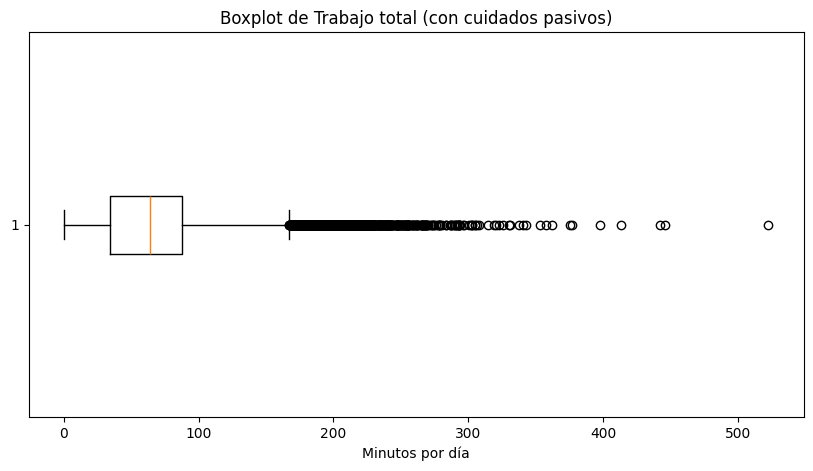

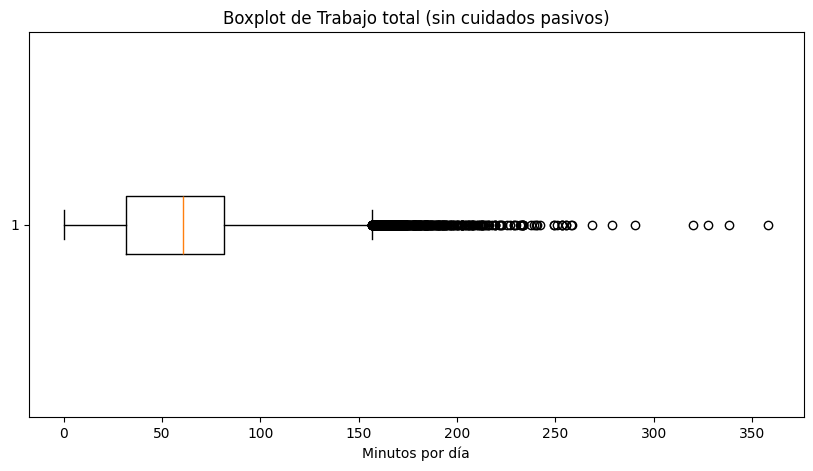

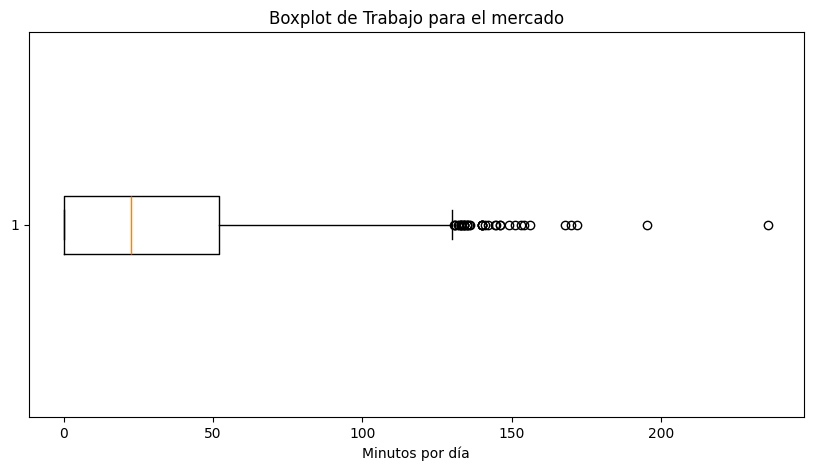

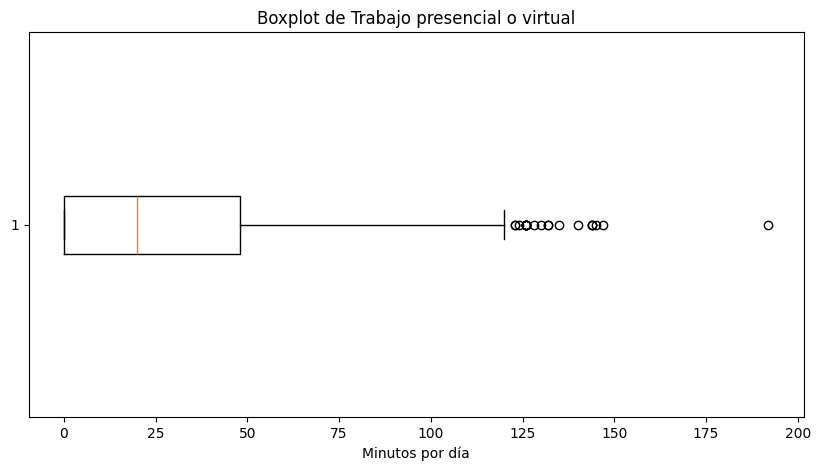

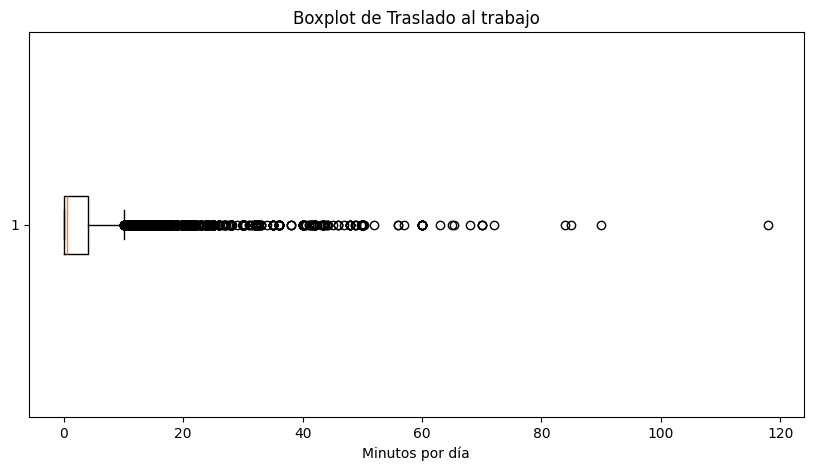

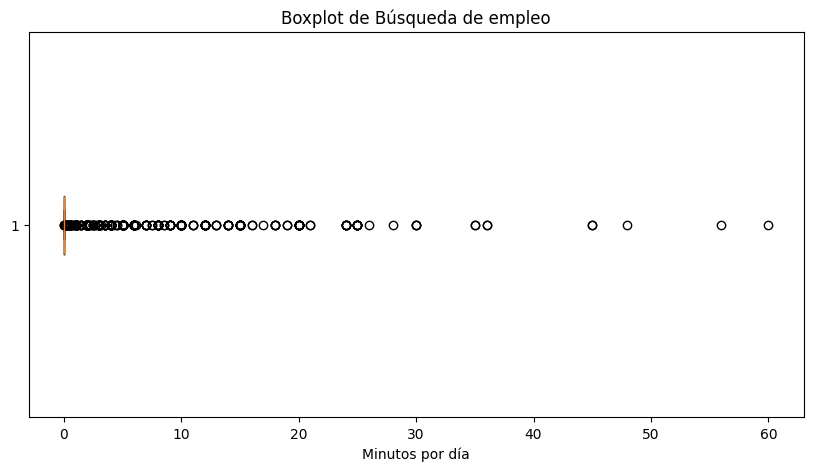

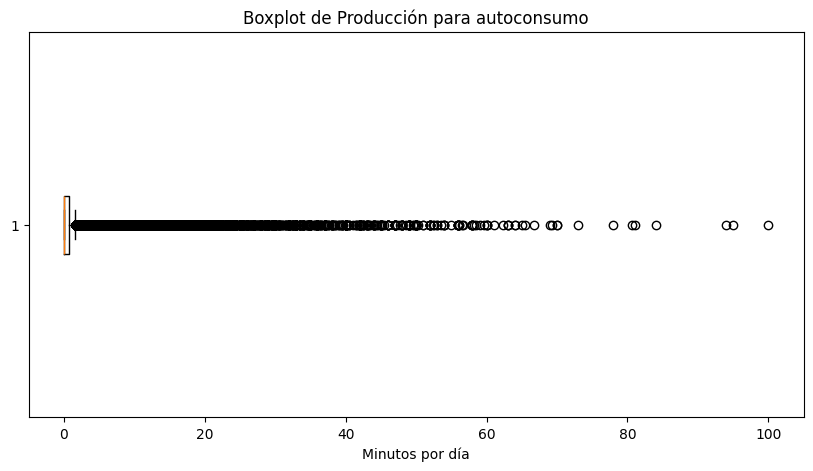

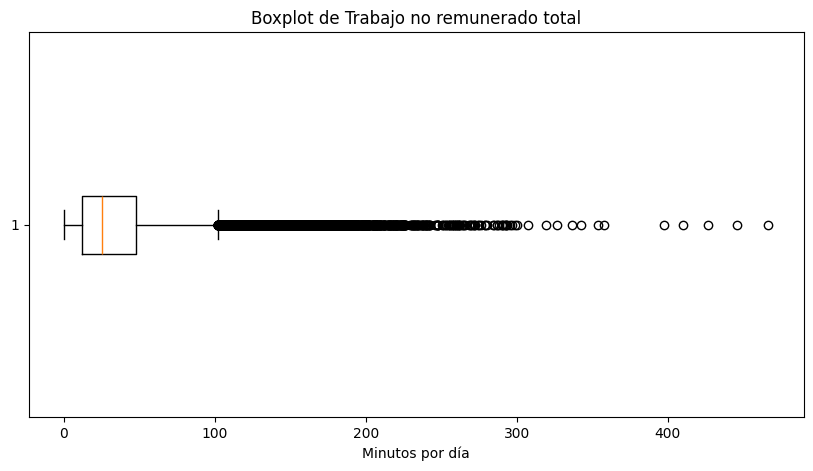

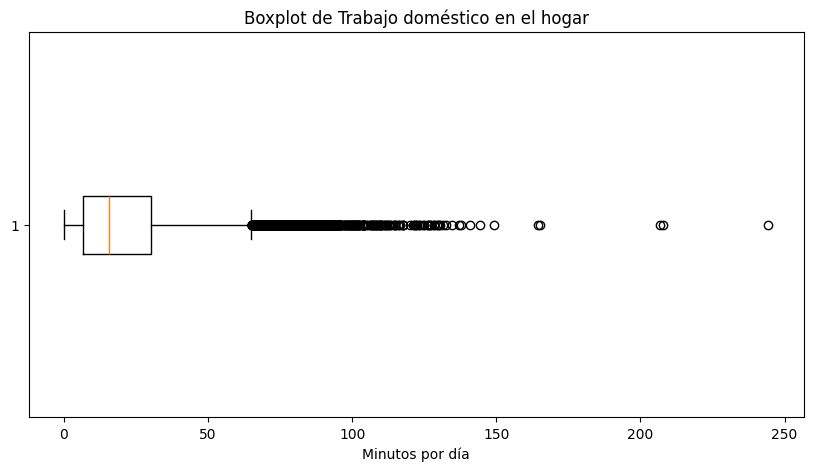

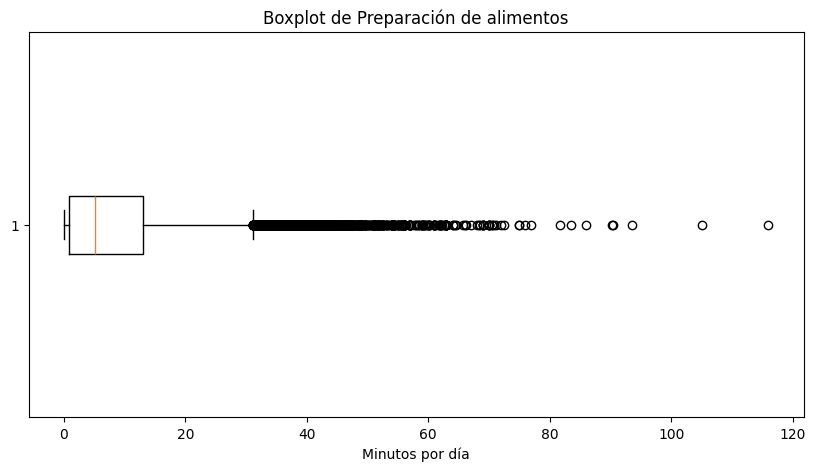

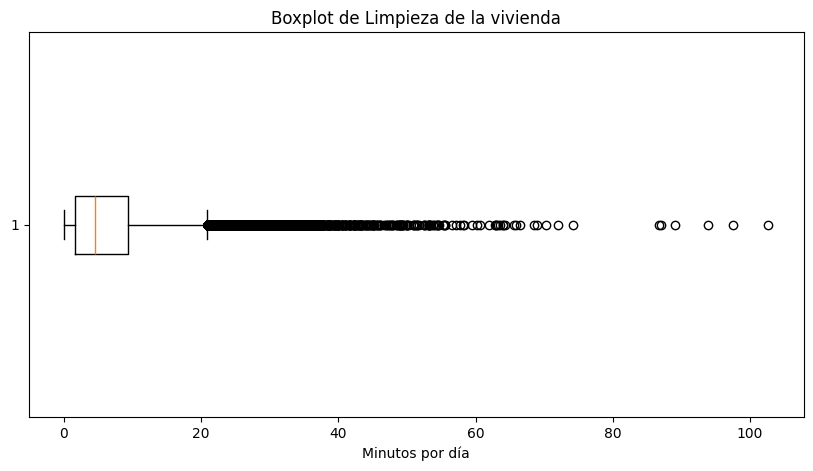

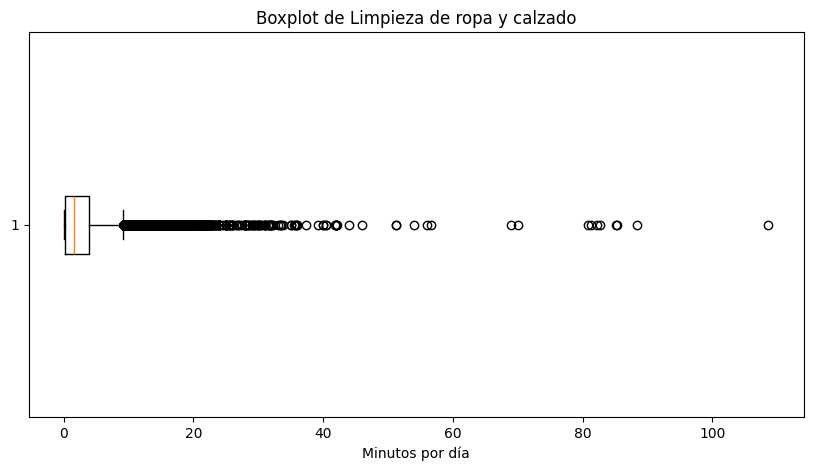

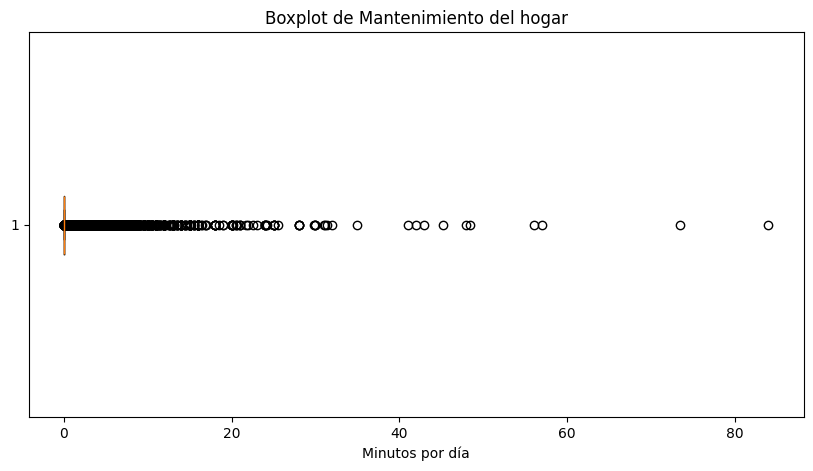

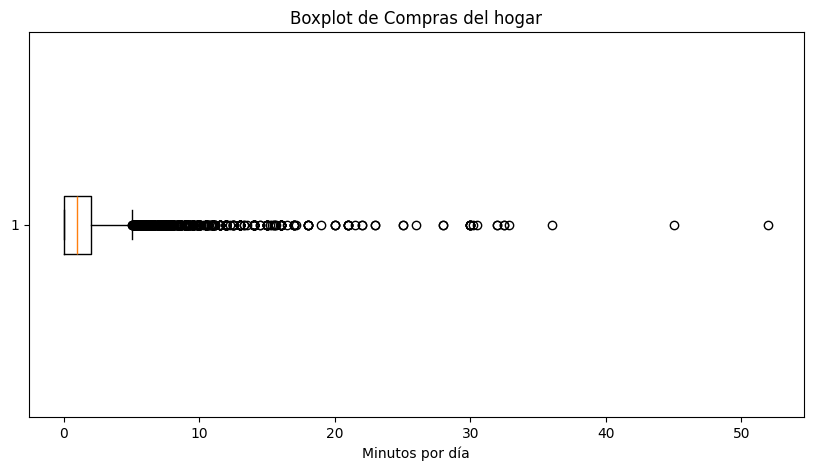

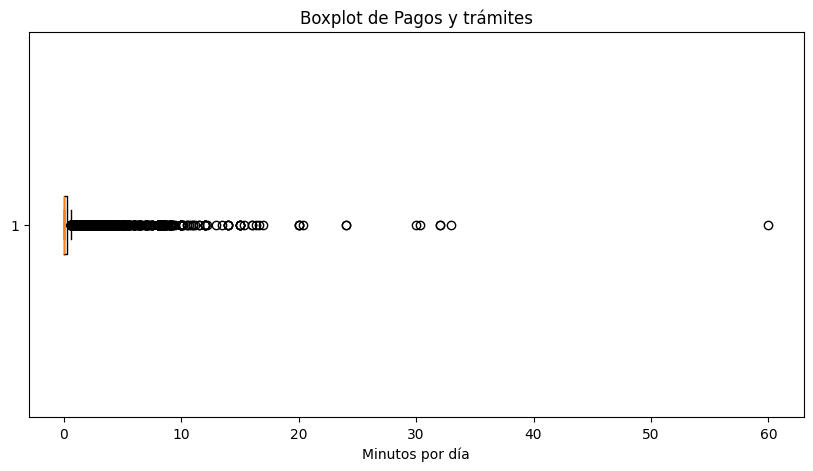

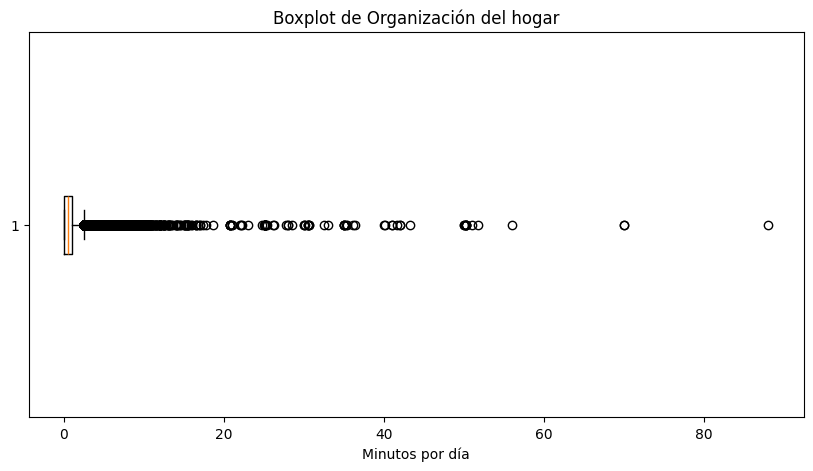

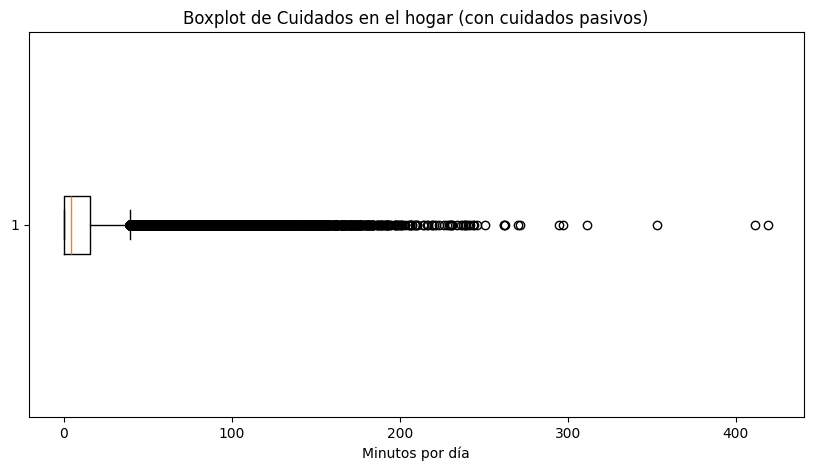

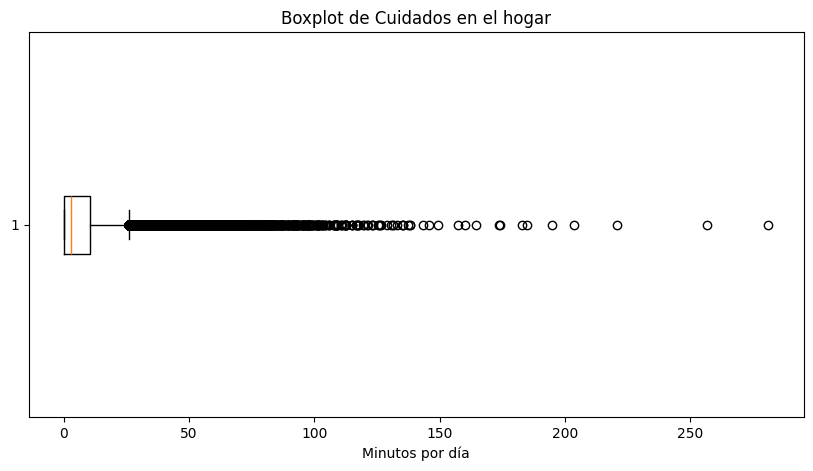

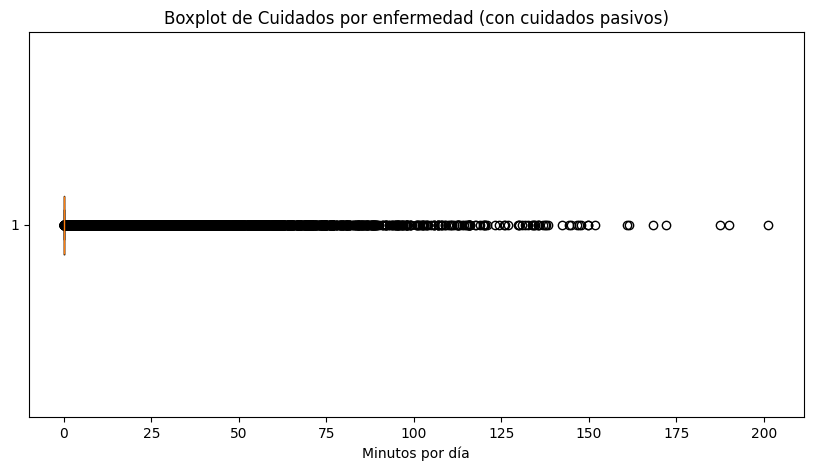

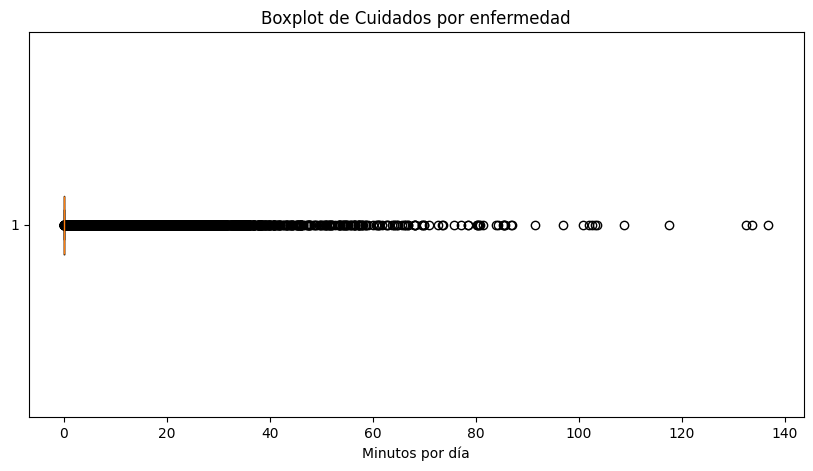

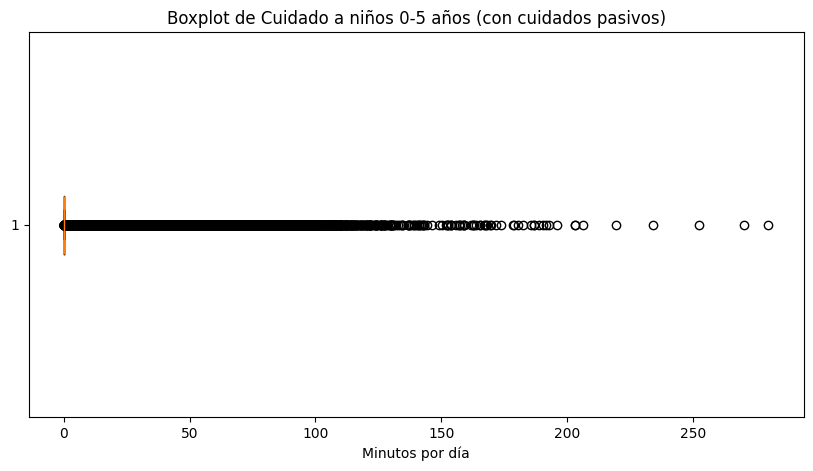

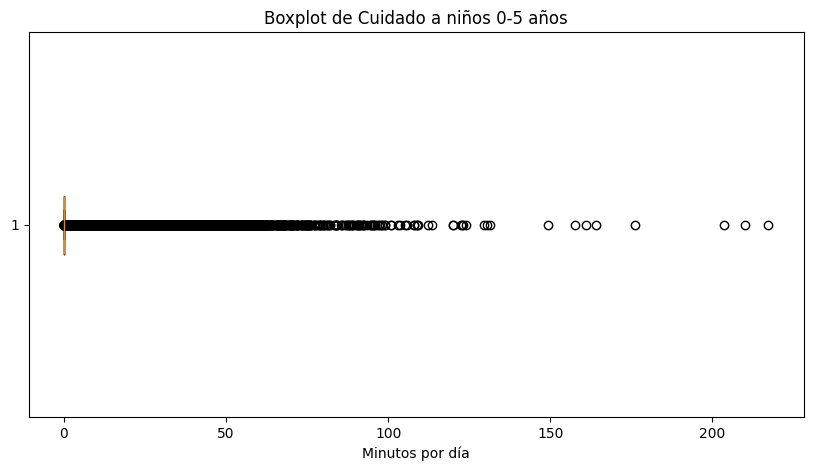

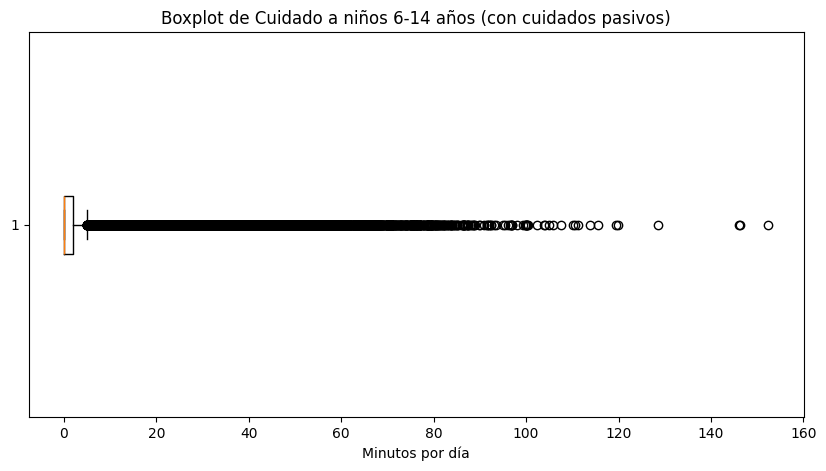

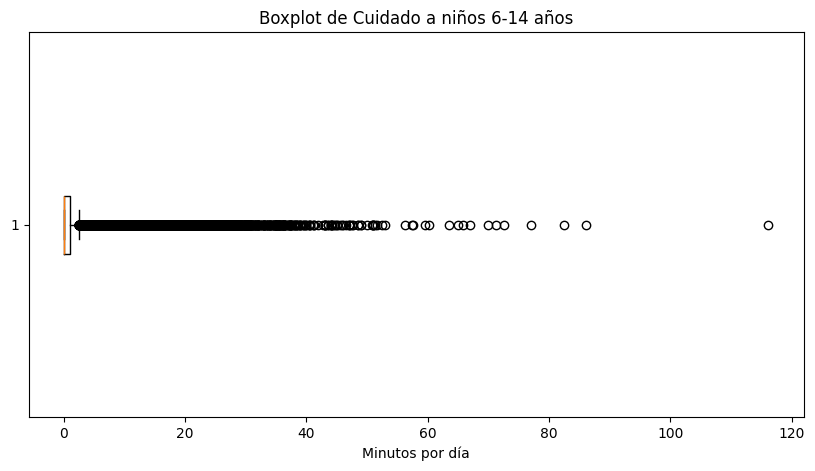

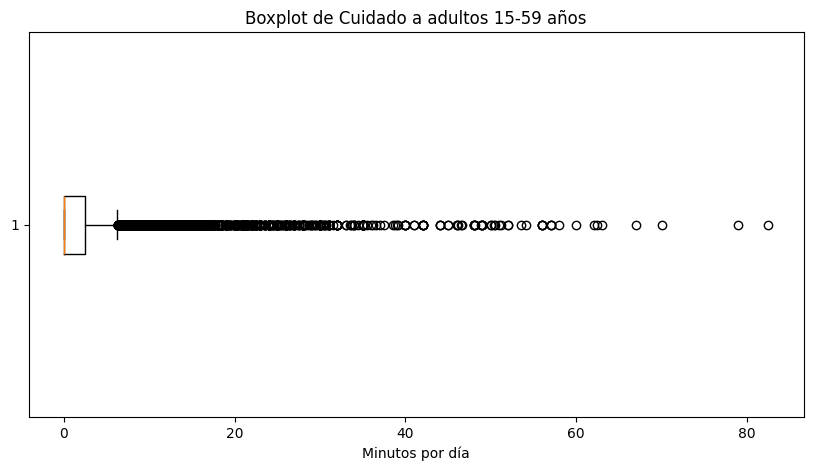

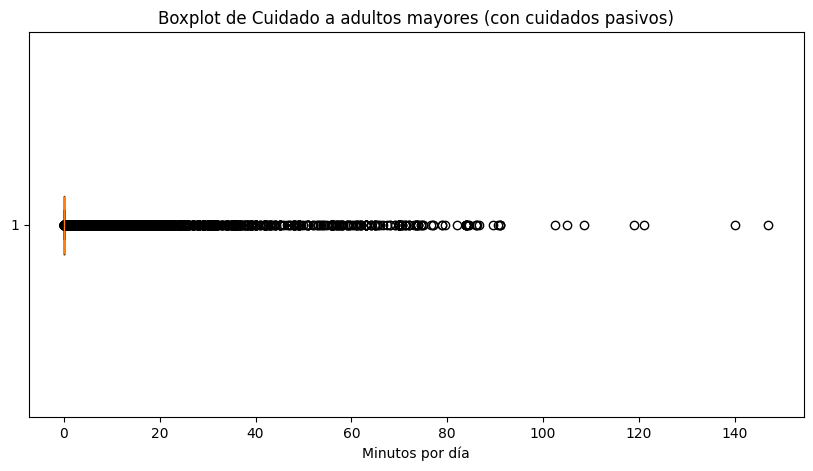

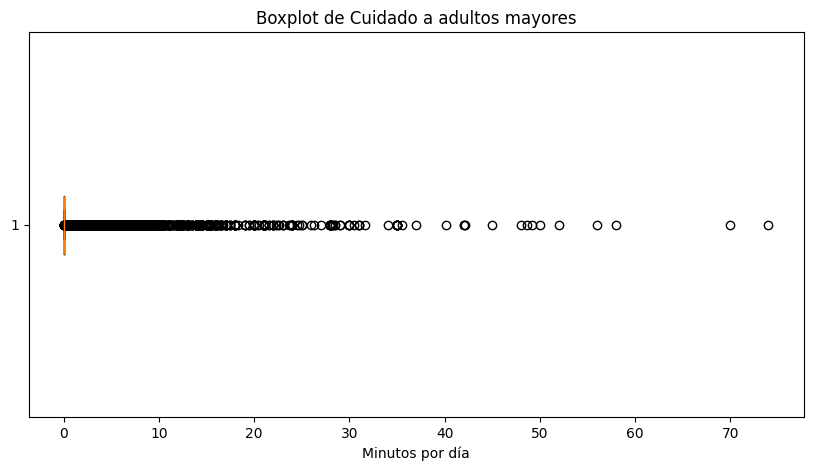

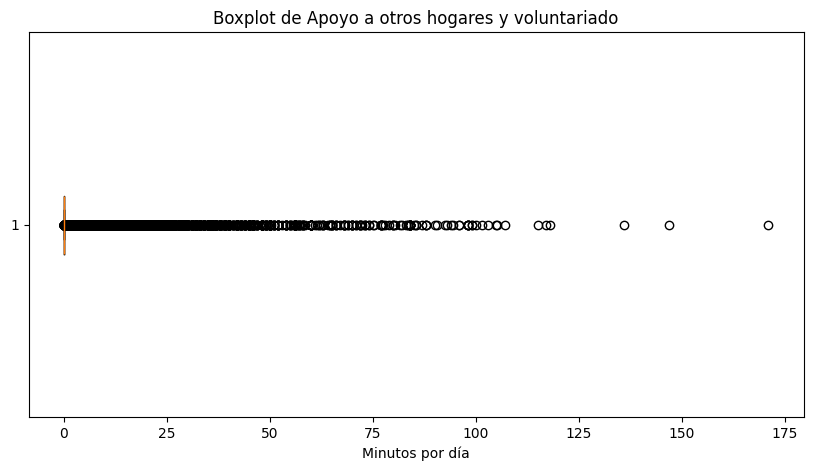

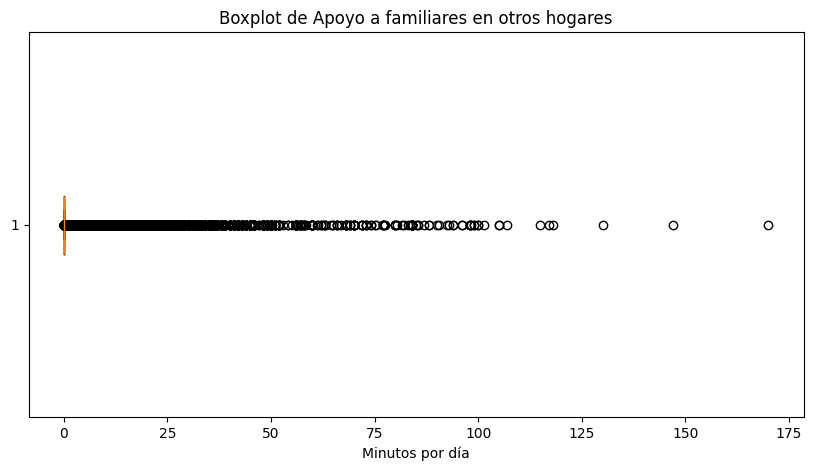

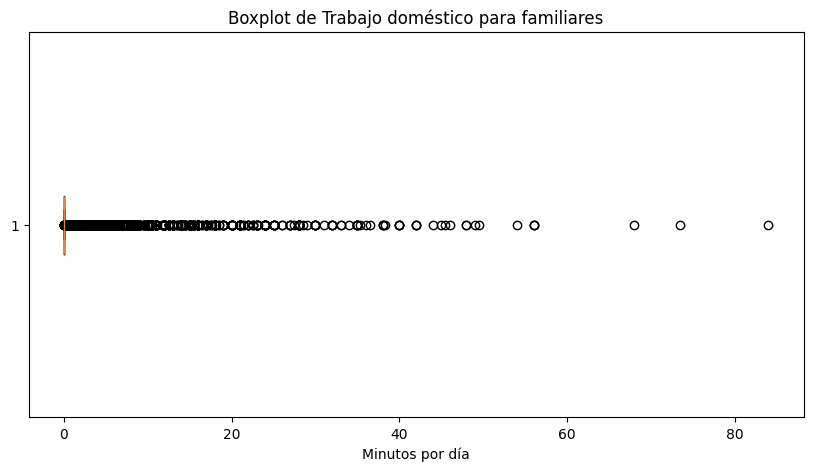

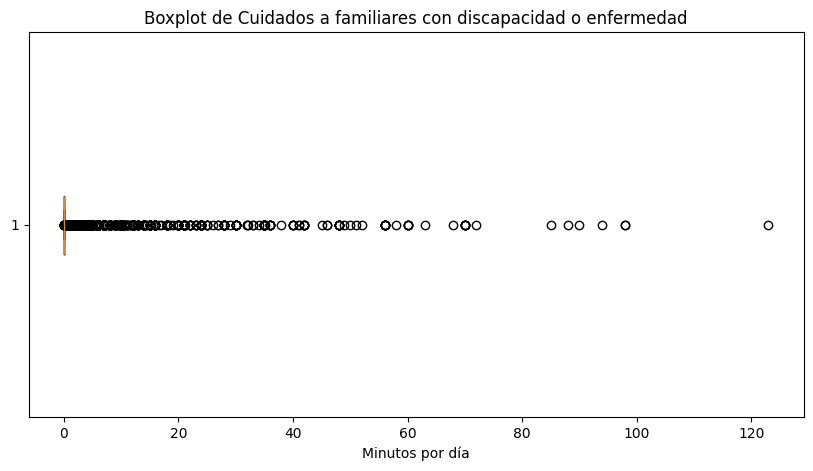

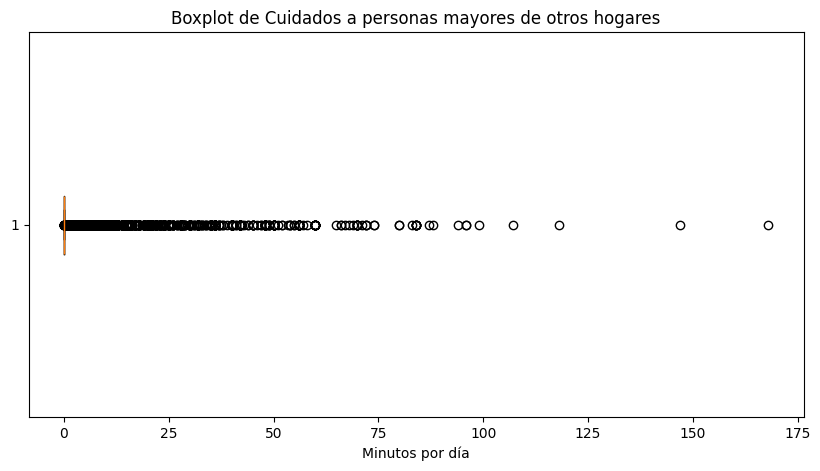

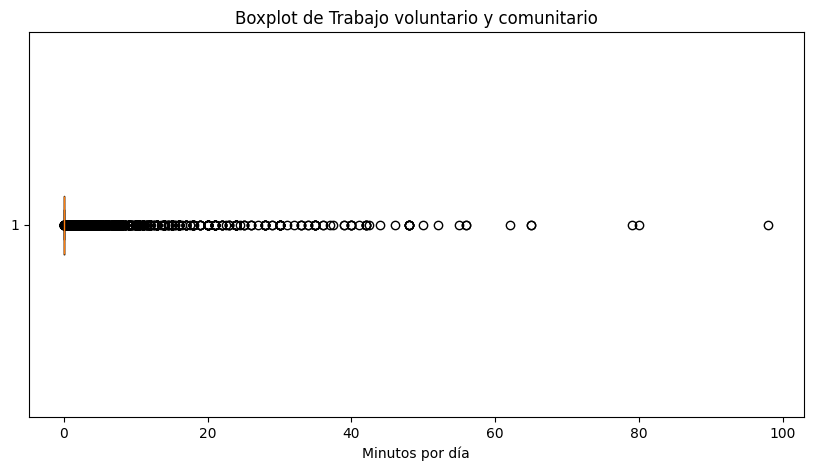

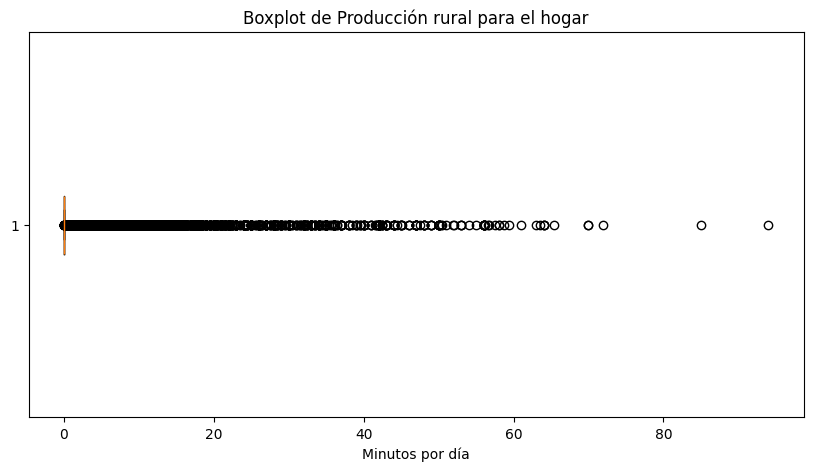

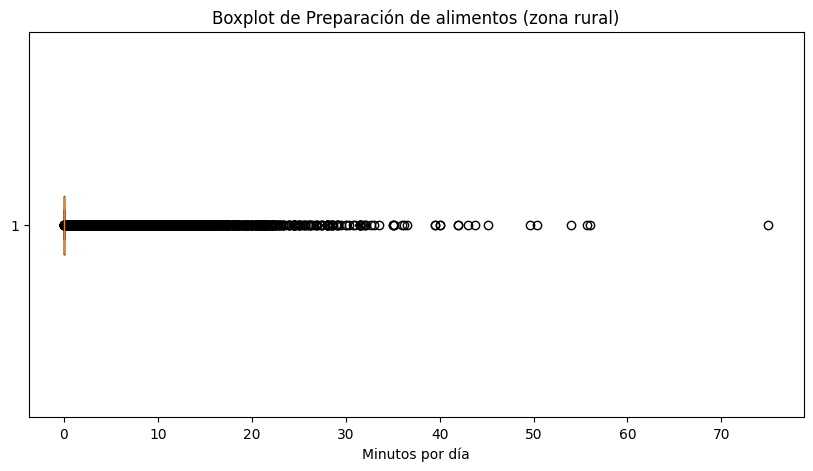

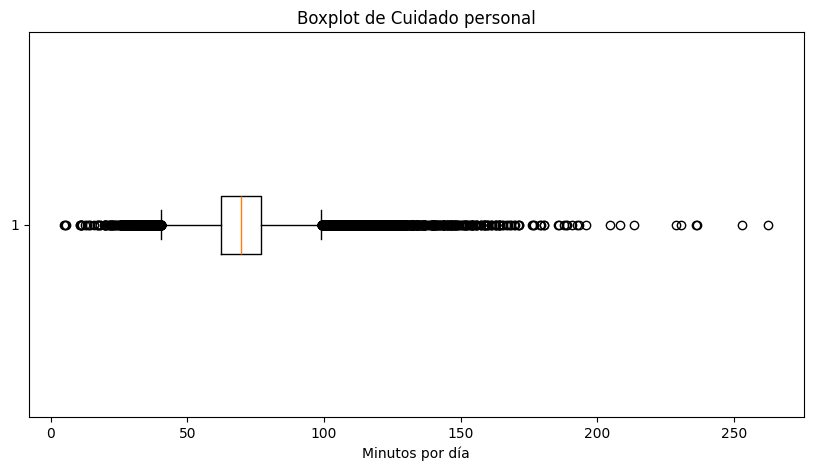

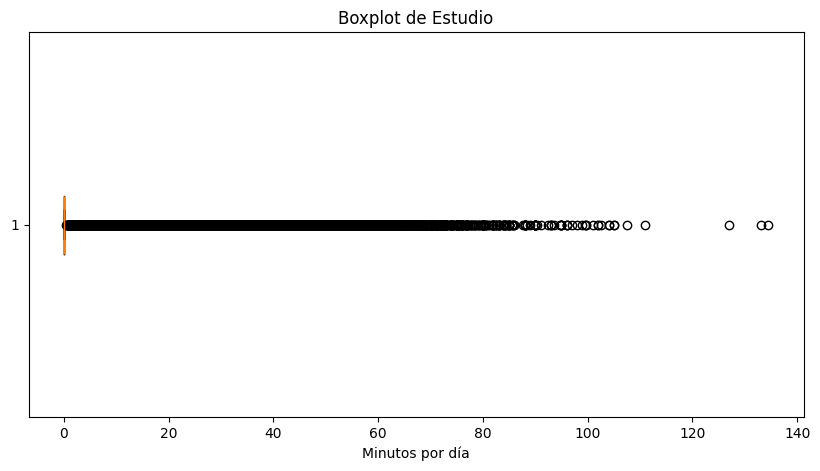

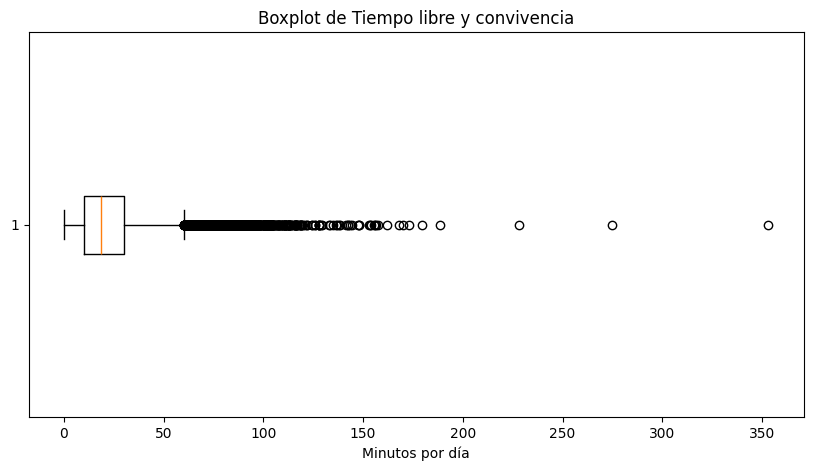

In [115]:
#boxplots de las variables de tiempo para detectar outliers
actividades = list(diccionario_actividades.values())
for actividad in actividades:
    plt.figure(figsize=(10, 5))
    plt.boxplot(dataTiempos[actividad].dropna(), vert=False)
    plt.title(f'Boxplot de {actividad}')
    plt.xlabel('Minutos por día')
    plt.show()


In [116]:
#registros con mas de 168 horas a la semana (24*7=168)
dataTiempos['Total_Tiempo'] = dataTiempos[actividades].sum(axis=1)
registros_excesivos = dataTiempos[dataTiempos['Total_Tiempo'] > 168]

In [117]:
registros_excesivos

,LLAVEMOD,LLAVEVIV,LLAVEHOG,Trabajo total (con cuidados pasivos),Trabajo total (sin cuidados pasivos),Trabajo para el mercado,Trabajo presencial o virtual,Traslado al trabajo,Búsqueda de empleo,Producción para autoconsumo,...,COND_DISC,COND_AEE,EST_DIS,UPM_DIS,FAC_PER,CONTROL,VIV_SEL,HOGAR,N_REN,Total_Tiempo
0,10039503105,10039503,100395031,25.833333,25.833333,0.000000,0.0,0.000000,0.0,0.000000,...,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,3,19,590,100395,3,1,5,249.833333
1,10039504101,10039504,100395041,30.166667,30.166667,23.083333,22.0,1.083333,0.0,0.000000,...,No tiene discapacidad,Ocupada,3,19,599,100395,4,1,1,198.500000
2,10039504102,10039504,100395041,71.750000,71.750000,8.833333,8.0,0.833333,0.0,0.000000,...,No tiene discapacidad,Ocupada,3,19,580,100395,4,1,2,429.333333
3,10039504103,10039504,100395041,17.416667,17.416667,0.000000,0.0,0.000000,0.0,0.000000,...,No tiene discapacidad,Estudiante,3,19,591,100395,4,1,3,210.083333
4,10039504104,10039504,100395041,20.583333,20.583333,13.000000,12.0,1.000000,0.0,0.000000,...,No tiene discapacidad,Ocupada,3,19,592,100395,4,1,4,202.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74047,326048702202,326048702,3260487022,52.333333,52.333333,0.000000,0.0,0.000000,0.0,0.000000,...,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,342,4197,592,3260487,2,2,2,370.166667
74048,326048703101,326048703,3260487031,33.833333,33.833333,0.000000,0.0,0.000000,0.0,2.000000,...,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,342,4197,587,3260487,3,1,1,260.333333
74049,326103520101,326103520,3261035201,56.500000,56.500000,30.000000,24.0,6.000000,0.0,0.000000,...,No tiene discapacidad,Ocupada,342,4203,586,3261035,20,1,1,360.666667
74050,326103520102,326103520,3261035201,63.500000,49.500000,0.000000,0.0,0.000000,0.0,0.000000,...,No tiene discapacidad,Se dedica a los quehaceres del hogar o al cuid...,342,4203,576,3261035,20,1,2,405.500000


In [ ]:
"""
tratar_outliers.py
==================
Tratamiento de valores atípicos en las columnas de actividades de tiempo
del dataset tvar_crea_etiquetado.csv (ENUT 2024).

Estrategia en dos pasos:
  1. Tope duro a 168 horas (límite físico: 24h × 7 días = 168h/semana).
     Ninguna actividad puede ocupar más horas que las que tiene la semana.
  2. Winsorización al percentil 99 dentro del rango 0–168h.
     Recorta los valores extremos que siguen siendo estadísticamente
     atípicos sin eliminar registros del dataset.

Nota sobre Total_Tiempo:
  Es normal que supere 168h porque las categorías de la ENUT se
  superponen por diseño (ej. cuidados pasivos se contabilizan dentro
  del tiempo de trabajo Y dentro del tiempo de cuidados).
  No se aplica ningún filtro sobre esa columna.
"""
LIMITE_SEMANAL = 168
print("\n── Paso 1: aplicando tope duro a 168h ──")
df_clean = dataTiempos.copy()

registros_corregidos_paso1 = {}
for col in actividades:
    mask = df_clean[col] > LIMITE_SEMANAL
    n = mask.sum()
    if n > 0:
        df_clean.loc[mask, col] = LIMITE_SEMANAL
        registros_corregidos_paso1[col] = n

print(f"  Columnas afectadas: {len(registros_corregidos_paso1)}")
for col, n in sorted(registros_corregidos_paso1.items(), key=lambda x: -x[1]):
    print(f"    {col:<55} → {n:>5} valores recortados a 168h")



── Paso 1: aplicando tope duro a 168h ──
  Columnas afectadas: 15
    Trabajo total (con cuidados pasivos)                    →  1316 valores recortados a 168h
    Trabajo no remunerado total                             →   609 valores recortados a 168h
    Trabajo total (sin cuidados pasivos)                    →   282 valores recortados a 168h
    Cuidados en el hogar (con cuidados pasivos)             →   154 valores recortados a 168h
    Cuidado personal                                        →    31 valores recortados a 168h
    Cuidado a niños 0-5 años (con cuidados pasivos)         →    25 valores recortados a 168h
    Cuidados en el hogar                                    →     9 valores recortados a 168h
    Tiempo libre y convivencia                              →     8 valores recortados a 168h
    Cuidados por enfermedad (con cuidados pasivos)          →     5 valores recortados a 168h
    Trabajo para el mercado                                 →     4 valores recortados 

In [119]:
TOPES = {
    # ── Trabajo productivo y de mercado ───────────────────────────────────
    "Trabajo total (sin cuidados pasivos)":                 84,
    "Trabajo para el mercado":                              84,
    "Trabajo presencial o virtual":                         84,
    "Traslado al trabajo":                                  42,   # 7h/día × 6 días
    "Búsqueda de empleo":                                   40,
    "Producción para autoconsumo":                          70,
 
    # ── Trabajo doméstico no remunerado ───────────────────────────────────
    "Trabajo no remunerado total":                          84,
    "Trabajo doméstico en el hogar":                        84,
    "Preparación de alimentos":                             42,
    "Limpieza de la vivienda":                              42,
    "Limpieza de ropa y calzado":                           42,
    "Mantenimiento del hogar":                              42,
    "Compras del hogar":                                    28,
    "Pagos y trámites":                                     28,
    "Organización del hogar":                               42,
 
    # ── Cuidados dentro del hogar ─────────────────────────────────────────
    "Cuidados en el hogar":                                 84,
    "Cuidados por enfermedad":                              84,
    "Cuidado a niños 0-5 años":                             84,
    "Cuidado a niños 6-14 años":                            56,
    "Cuidado a adultos 15-59 años":                         56,
    "Cuidado a adultos mayores":                            84,
 
    # ── Apoyo a otros hogares y voluntariado ─────────────────────────────
    "Apoyo a otros hogares y voluntariado":                 42,
    "Apoyo a familiares en otros hogares":                  42,
    "Trabajo doméstico para familiares":                    42,
    "Cuidados a familiares con discapacidad o enfermedad":  56,
    "Cuidados a personas mayores de otros hogares":         56,
    "Trabajo voluntario y comunitario":                     42,
 
    # ── Actividades rurales ───────────────────────────────────────────────
    "Producción rural para el hogar":                       70,
    "Preparación de alimentos (zona rural)":                42,
 
    # ── Cuidado personal, estudio y tiempo libre ─────────────────────────
    "Cuidado personal":                                    119,   # incluye sueño
    "Estudio":                                              70,
    "Tiempo libre y convivencia":                           98,
}

In [120]:
topes_presentes = {col: tope for col, tope in TOPES.items() if col in df_clean.columns}
print(f"  Columnas con tope definido encontradas: {len(topes_presentes)}")

  Columnas con tope definido encontradas: 32


In [121]:
print("\n=== DIAGNÓSTICO ANTES DEL TRATAMIENTO ===")
rows = []
for col, tope in topes_presentes.items():
    serie = df_clean[col].dropna()
    rows.append({
        "columna":      col[:50],
        "tope_dominio": tope,
        "max_original": round(serie.max(), 1),
        "p99":          round(serie.quantile(0.99), 1),
        "n_sobre_tope": int((serie > tope).sum()),
    })
diag = pd.DataFrame(rows).set_index("columna")
print(diag[diag["n_sobre_tope"] > 0].to_string())


=== DIAGNÓSTICO ANTES DEL TRATAMIENTO ===
                                                    tope_dominio  max_original    p99  n_sobre_tope
columna                                                                                            
Trabajo total (sin cuidados pasivos)                          84         168.0  148.0         16787
Trabajo para el mercado                                       84         168.0   93.4          1623
Trabajo presencial o virtual                                  84         168.0   84.0           672
Traslado al trabajo                                           42         118.0   21.0            77
Búsqueda de empleo                                            40          60.0    0.0             5
Producción para autoconsumo                                   70         100.0   23.0             8
Trabajo no remunerado total                                   84         168.0  160.5          6301
Trabajo doméstico en el hogar                            

In [122]:
print("\n── Aplicando topes por dominio ──")
total_recortados = 0
 
for col, tope in topes_presentes.items():
    mask = df_clean[col] > tope
    n = mask.sum()
    if n > 0:
        df_clean.loc[mask, col] = tope
        total_recortados += n
        print(f"  {col[:55]:<55} → {n:>5} valores recortados a {tope}h")
 
print(f"\n  Total de celdas recortadas: {total_recortados:,}")
print(f"  Filas eliminadas: 0")
 


── Aplicando topes por dominio ──
  Trabajo total (sin cuidados pasivos)                    → 16787 valores recortados a 84h
  Trabajo para el mercado                                 →  1623 valores recortados a 84h
  Trabajo presencial o virtual                            →   672 valores recortados a 84h
  Traslado al trabajo                                     →    77 valores recortados a 42h
  Búsqueda de empleo                                      →     5 valores recortados a 40h
  Producción para autoconsumo                             →     8 valores recortados a 70h
  Trabajo no remunerado total                             →  6301 valores recortados a 84h
  Trabajo doméstico en el hogar                           →   318 valores recortados a 84h
  Preparación de alimentos                                →   452 valores recortados a 42h
  Limpieza de la vivienda                                 →   144 valores recortados a 42h
  Limpieza de ropa y calzado                           

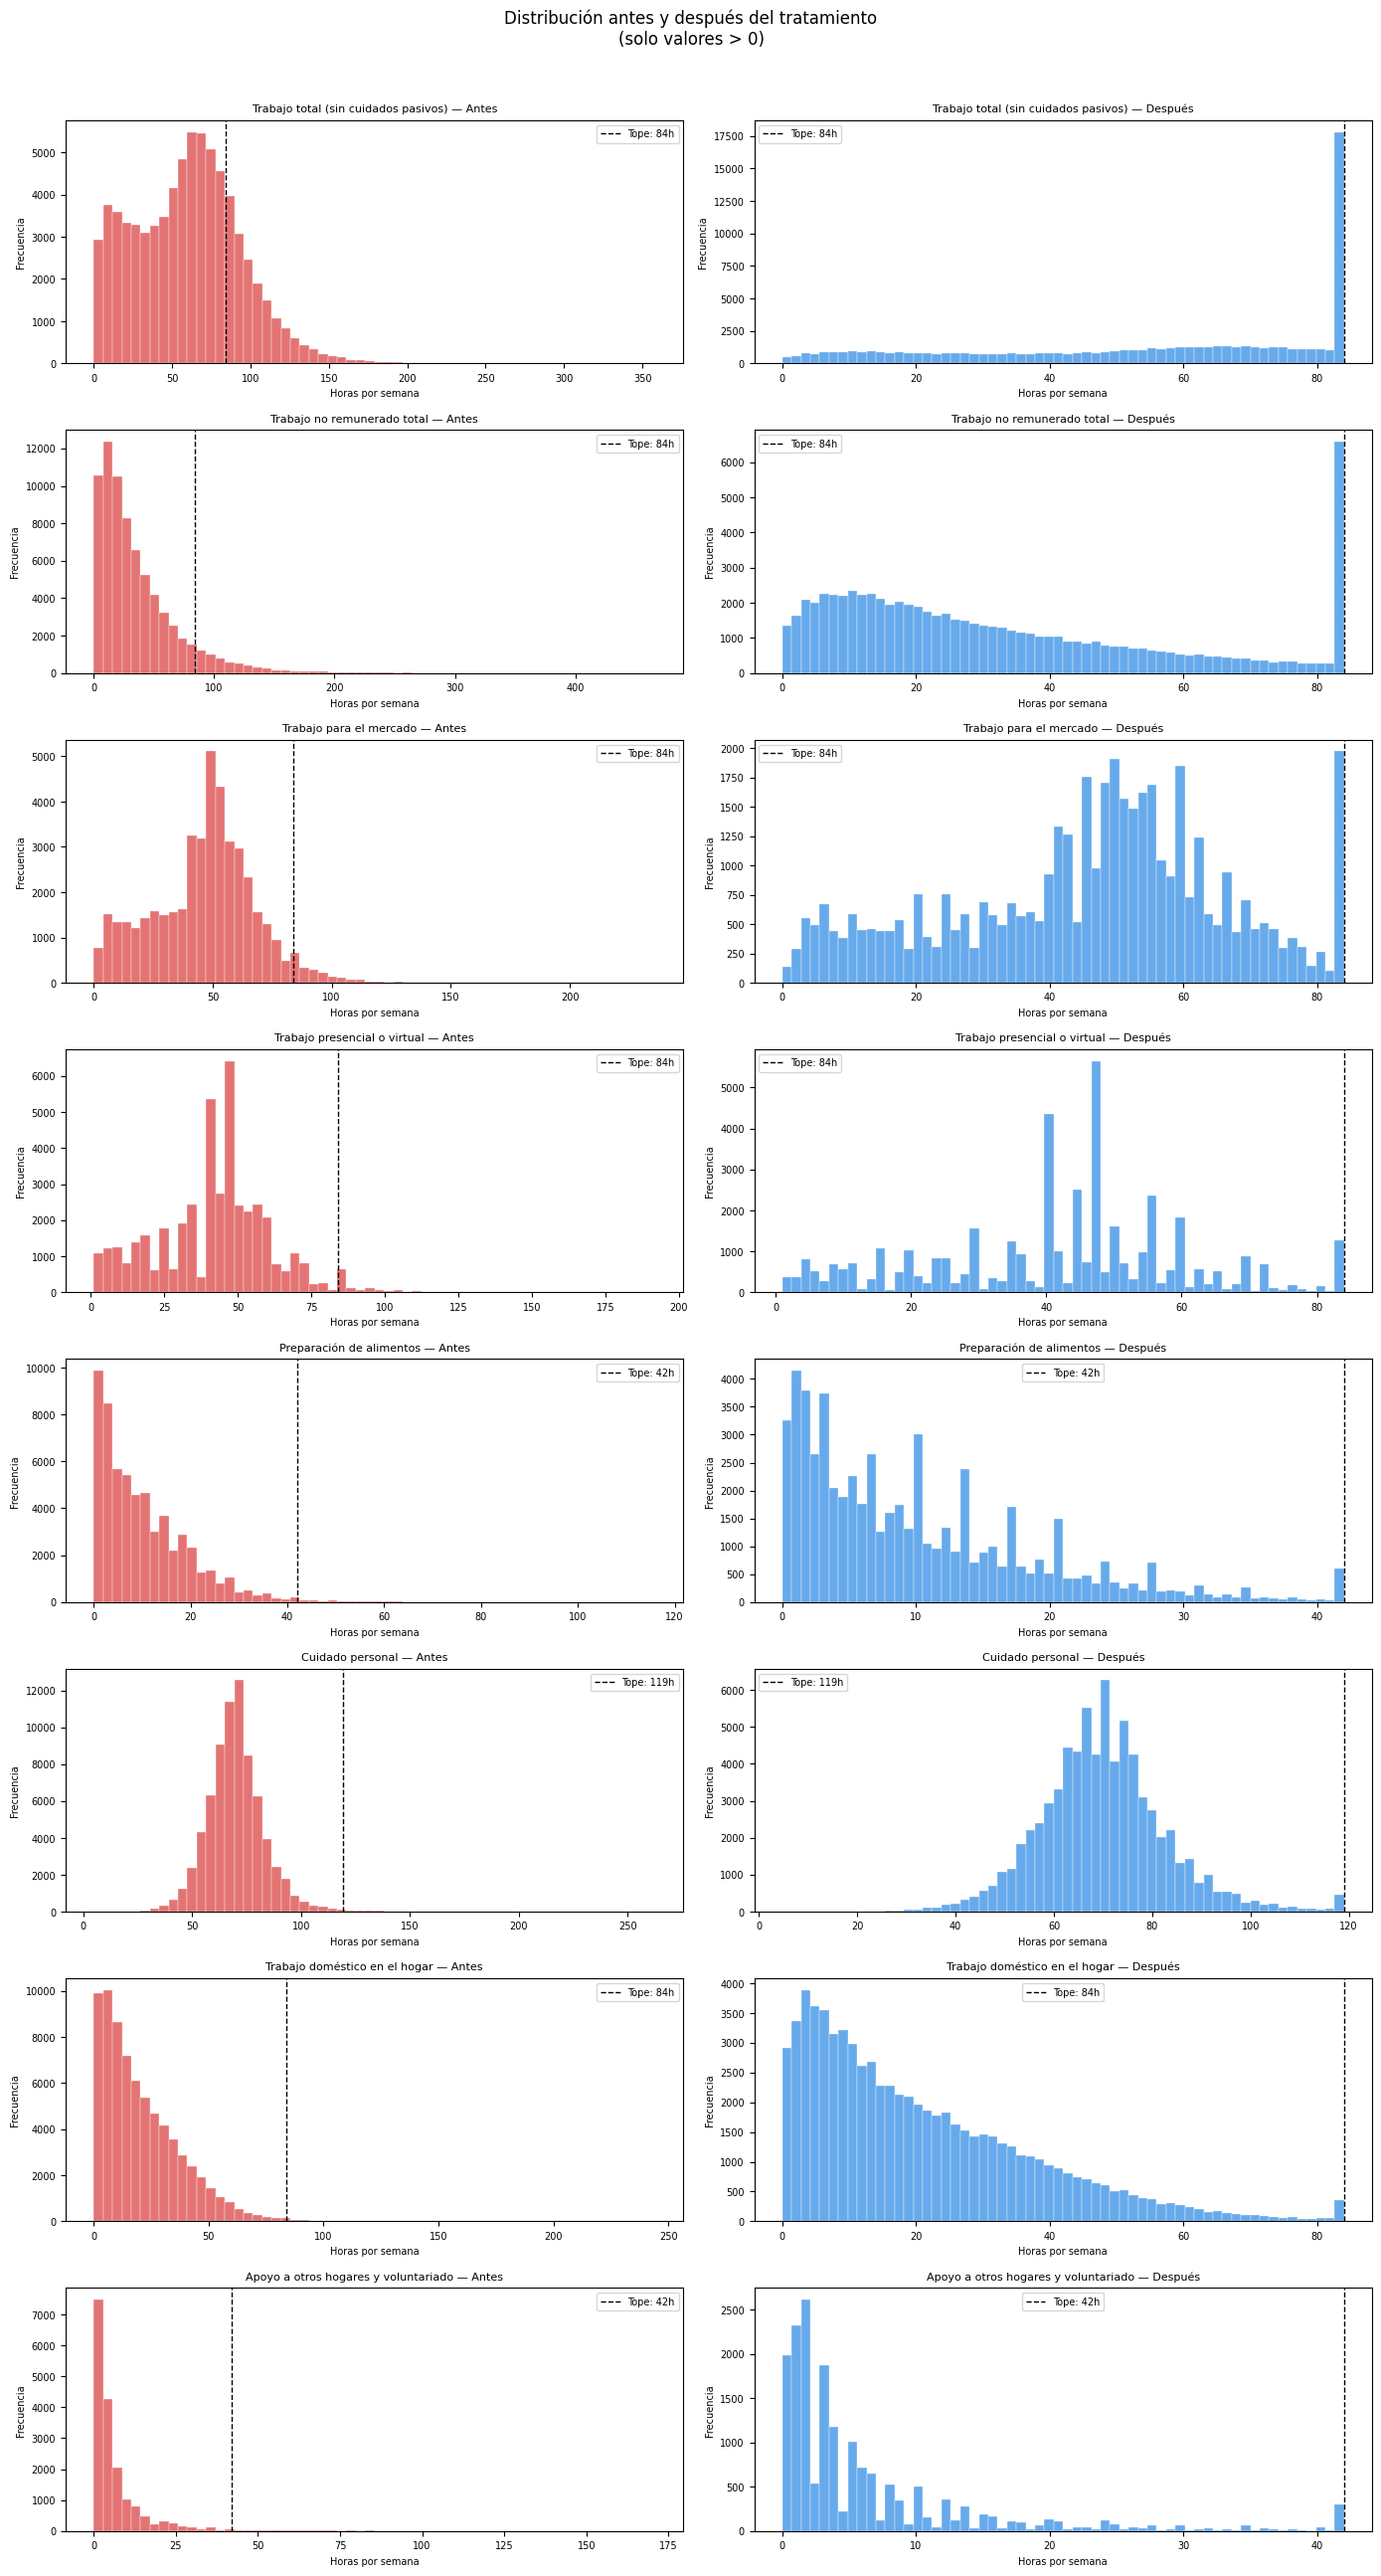


Gráfica guardada como: outliers_comparacion.png


In [123]:
# ── Visualización ─────────────────────────────────────────────────────────
cols_afectadas = (
    pd.Series({col: int((dataTiempos[col] > tope).sum())
               for col, tope in topes_presentes.items()})
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)
 
fig, axes = plt.subplots(len(cols_afectadas), 2,
                          figsize=(14, 3.2 * len(cols_afectadas)))
fig.suptitle("Distribución antes y después del tratamiento\n(solo valores > 0)",
             fontsize=12, y=1.01)
 
for i, col in enumerate(cols_afectadas):
    tope = topes_presentes[col]
    for j, (data, color, titulo) in enumerate([
        (dataTiempos[col][dataTiempos[col] > 0].dropna(),            "#E05C5C", "Antes"),
        (df_clean[col][df_clean[col] > 0].dropna(), "#4C9BE8", "Después"),
    ]):
        ax = axes[i][j]
        ax.hist(data, bins=60, color=color, edgecolor="white", linewidth=0.3, alpha=0.85)
        ax.axvline(tope, color="black", linestyle="--", linewidth=1,
                   label=f"Tope: {tope}h")
        label = col if len(col) <= 38 else col[:36] + "…"
        ax.set_title(f"{label} — {titulo}", fontsize=8)
        ax.set_xlabel("Horas por semana", fontsize=7)
        ax.set_ylabel("Frecuencia", fontsize=7)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)
 
plt.tight_layout()
plt.savefig("outliers_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGráfica guardada como: outliers_comparacion.png")

In [125]:
df_clean.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"\nArchivo guardado como: {OUTPUT_CSV}")


Archivo guardado como: tvar_crea_etiquetado.csv
